##### Lee, Keinath, Cianfarano and Brandon (2025). Identifying representational structure in CA1 to benchmark theoretical models of cognitive mapping. Neuron 113(2): 307-320. https://doi.org/10.1016/j.neuron.2024.10.027

In this notebook, we will run analyses and generate plots for panels from Figure 1, including event rate maps plotting of example cells, measurement of within-session split-half spatial reliability, Bayesian decoding of animal position, representational similarity matrix generation from entire rate maps, nonmetric multidimensional scaling, dendrogram clustering, and measurement of across-animal representational similarity in remapping of CA1.

First load in all packages and functions for analyses and plotting

In [1]:
from src.utils import *
from src.plots import *

Define path where georepca1 folder is located, including dataset manually added to the georepca1/data folder
e.g., r"Users/YourName/Documents/georepca1"

In [5]:
p = r"" # add path to georepca1 folder
os.chdir(p)

Define list of animal IDs

In [3]:
animals = ['QLAK-CA1-08', 'QLAK-CA1-30', 'QLAK-CA1-50', 'QLAK-CA1-51', 'QLAK-CA1-56', 'QLAK-CA1-74', 'QLAK-CA1-75']

Load in dataset from example animal

In [6]:
# Load third animal in dataset as example
animal = animals[2]
dat = load_dat(animal, p, format="joblib")

Loading preprocessed data for animal QLAK-CA1-50


### Figure 1C
Plot example event rate maps from CA1 neurons across sessions in a geometric sequence


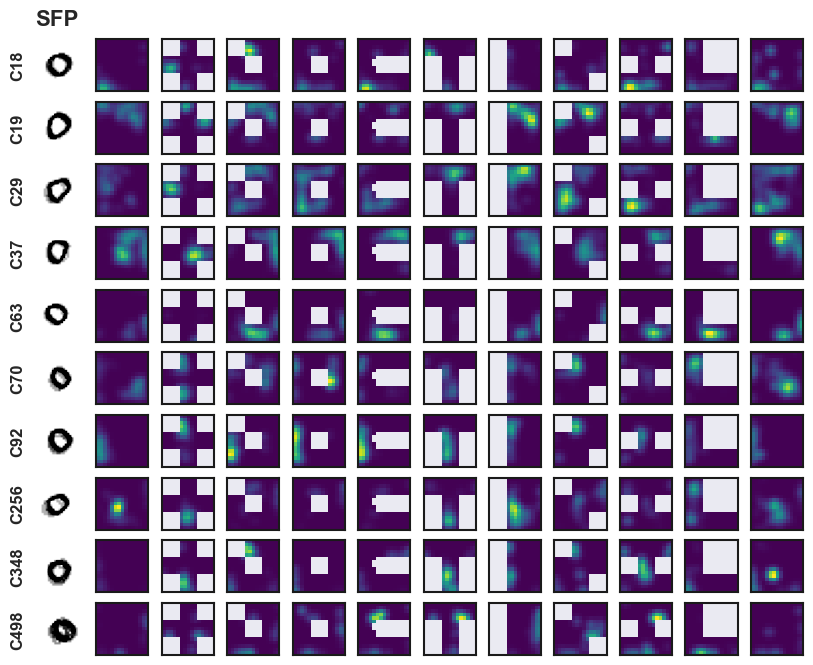

In [7]:
# Use example cells and sessions from paper
example_cells_idx = np.array([17, 18, 28, 36, 62, 69, 91, 255, 347, 497])
example_days_idx = np.arange(20, 31)
# Index example maps and create contours from spatial footprints ("SFPs")
example_maps = {"smoothed": dat[animal]["maps"]["smoothed"][:, :, example_cells_idx, :][:, :, :, example_days_idx]}
example_sfps = trace_sfps(dat[animal]['SFPs'])[:, :, example_cells_idx, :][:, :, :, example_days_idx]
plot_maps(example_maps, animal,  p, example_sfps, example_cells_idx, unsmoothed=False, cmap='viridis')


### Figure 1E-F
Split half spatial reliability and Bayesian position decoding accuracy

In [8]:
# OPTIONAL! WARNING - Long run time!
# Calculate split-half spatial reliability for all recorded cells within each session
for animal in animals:
    dat = load_dat(animal, p, format="joblib")
    p_vals, _ = get_shr_within(dat, animal)
    joblib.dump(p_vals, os.path.join(p, "results", f"{animal}_shr"))

In [9]:
# OPTIONAL! WARNING - Long run time!
# fit bayesian decoder with flat priors to each day position within day (cross-validated)
# return decoding error (mean each day) for all animals and save to results folder
within_decoding = {}
for animal in animals:
    within_decoding[animal] = {}
    dat = load_dat(animal, p, format="joblib")
    within_decoding[animal]['envs'] = dat[animal]['envs'].squeeze()
    within_decoding[animal]['decoding_error'] = \
        decode_position_within(dat[animal]['position'].T, dat[animal]['trace'].T, dat[animal]['maps']['smoothed'])[0]
joblib.dump(within_decoding, os.path.join(p, "results", "within_decoding"))

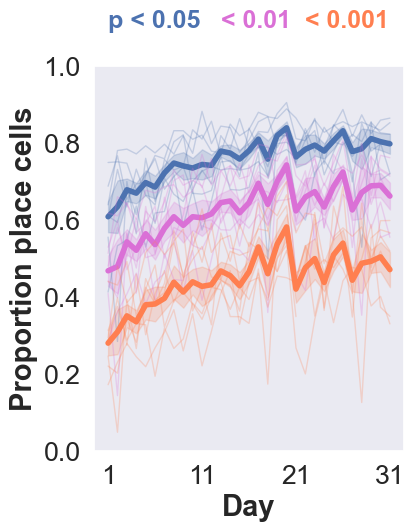

One-way ANOVA for SHR across days: 
               df       sum_sq   mean_sq          F         PR(>F)
C(Day)       30.0    38.044337  1.268145  37.400643  5.713181e-215
Residual  69713.0  2363.760478  0.033907        NaN            NaN


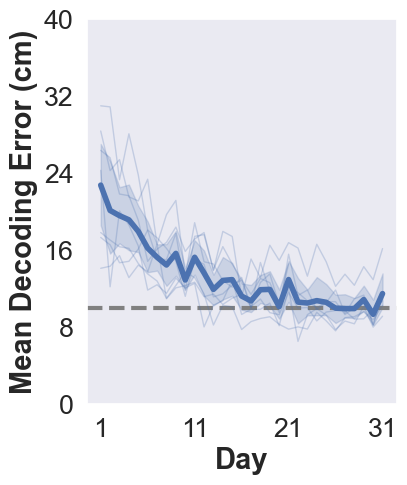

One-way ANOVA for decoding error across days: 
             df       sum_sq    mean_sq         F        PR(>F)
C(Day)     30.0  2492.695189  83.089840  7.984459  4.419462e-20
Residual  176.0  1831.534494  10.406446       NaN           NaN


In [14]:
# Load split-half reliability p values from all animals and all sessions into single dataframe
# if you ran optional the kernels above, run the line:
# df_pvals = get_all_shr_pvals(animals, p)
# else if you skipped this step, then run:
df_pvals = joblib.load(os.path.join(p, "results", "df_shr_pvals"))
# STATS One-way ANOVA
plot_shr_pvals(df_pvals)
formula = 'SHR ~ C(Day)'
lm = ols(formula, df_pvals).fit()
print(f"One-way ANOVA for SHR across days: \n{anova_lm(lm)}")
df_decoding = get_all_decoding_within(animals, p)
plot_decoding_within_days(df_decoding)
formula = 'Error ~ C(Day)'
lm = ols(formula, df_decoding).fit()
print(f"One-way ANOVA for decoding error across days: \n{anova_lm(lm)}")
# Plot SHR and decoding error across all recordings


### Figure 1H-I
Rate map (whole, non-partitioned) representational similarity and nMDS embedding

In [15]:
# OPTIONAL! WARNING - Long run time!
# calculate the average map correlation across geometries, and plot as RSM and with non-metric MDS and dendrogram
mean_map_corr, _, labels, map_corr_animals_sequences = get_mean_map_corr(animals, p)
map_corr_dict = {"mean_map_corr": mean_map_corr,
                 "labels": labels,
                 "map_corr_animals_sequences": map_corr_animals_sequences}
joblib.dump(map_corr_dict, os.path.join(p, "results", "map_corr_envs"))
map_corr_dict = joblib.load(os.path.join(p, "results", "map_corr_envs"))
mean_map_corr, labels, map_corr_animals_sequences = map_corr_dict["mean_map_corr"], map_corr_dict["labels"], map_corr_dict["map_corr_animals_sequences"]

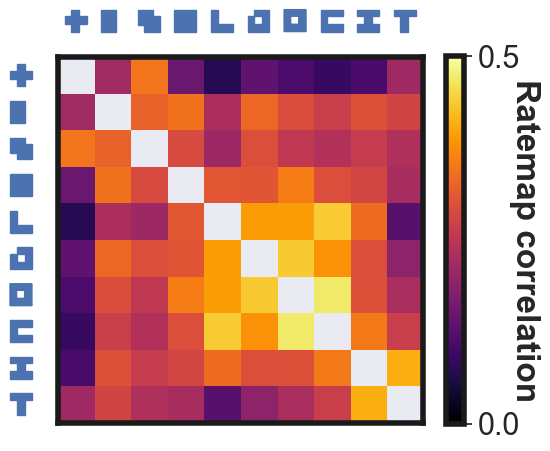

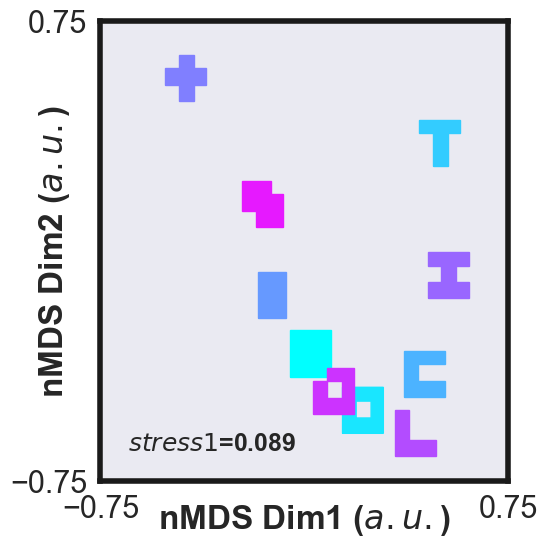

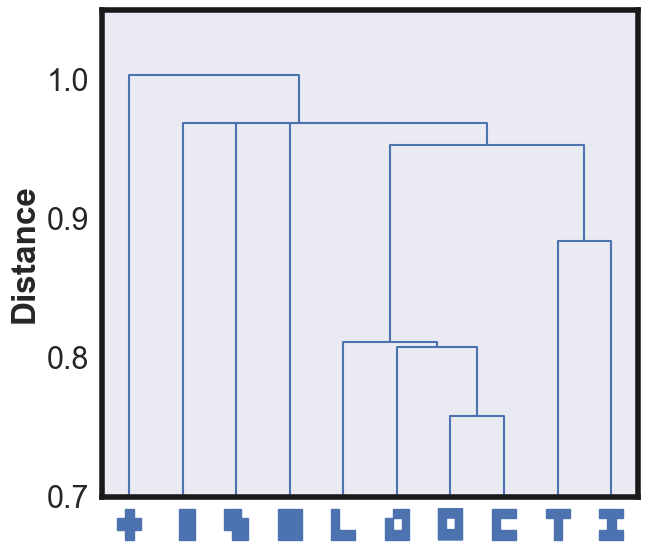

In [16]:
map_corr_envs = joblib.load(os.path.join(p, "results", "map_corr_envs"))
mean_map_corr, labels, map_corr_animals_sequences = map_corr_envs["mean_map_corr"], map_corr_envs["labels"], map_corr_envs["map_corr_animals_sequences"]

fig_h = plot_map_corr_rsm_ordered(mean_map_corr, labels)
fig_i = plot_map_corr_mds(mean_map_corr, labels)
fig_j = plot_map_corr_dendrogram(mean_map_corr, labels)

### Figure 1K
Calculate similarity of representations across animals

Calculating rate map correlation rsm similarity across animals: 100%|██████████| 7/7 [00:01<00:00,  4.35it/s]
Calculating rate map correlation rsm similarity across animals: 100%|██████████| 7/7 [00:01<00:00,  4.40it/s]
Calculating rate map correlation rsm similarity across animals: 100%|██████████| 7/7 [00:01<00:00,  5.91it/s]


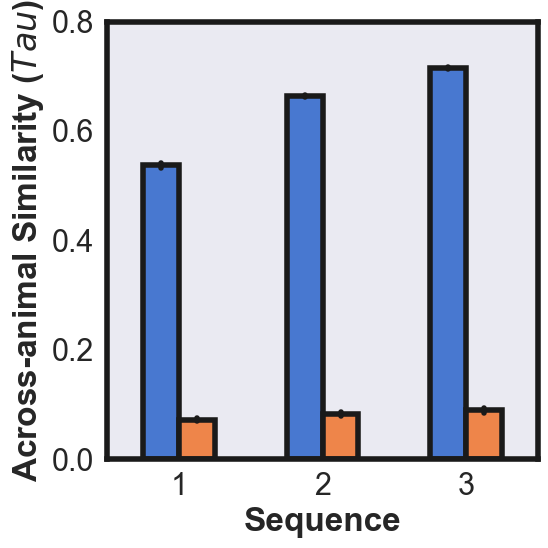

Two-way ANOVA for across-animal RSM similarity based on sequnece: 
                             df       sum_sq      mean_sq              F  \
C(Sequence)                 2.0    37.319981    18.659991    1679.225987   
C(Shuffle)                  1.0  1725.239284  1725.239284  155255.525214   
C(Sequence):C(Shuffle)      2.0    25.583175    12.791587    1151.124160   
Residual                22794.0   253.292784     0.011112            NaN   

                        PR(>F)  
C(Sequence)                0.0  
C(Shuffle)                 0.0  
C(Sequence):C(Shuffle)     0.0  
Residual                   NaN  


In [17]:
# Measure similarity of rsms across animals and format into dataframe
df_map_corr_animals_sequences = get_rsm_similarity_animals_sequences(animals, p)

# Plot results
fig_k = plot_across_animal_similarity(df_map_corr_animals_sequences)

# two-way ANOVA for effect of sequence and shuffle on across-animal remapping similarity (whole rate map)
formula = 'Fit ~ C(Sequence) + C(Shuffle) + C(Sequence):C(Shuffle)'
lm = ols(formula, df_map_corr_animals_sequences).fit()
print(f"Two-way ANOVA for across-animal RSM similarity based on sequnece: \n{anova_lm(lm)}")